## Градиентный спуск на NumPy

Рассмотрим функцию $f(\mathbf{x})$, $x \sim (2)$ на отрезке [0, 10]:

$$f(\mathbf{x}) = \sin(x_1)\cos(x_2) + \sin(0.5x_1)\cos(0.5 x_2)$$

1. Реализуйте функцию в векторизованном виде, т.е. для матрицы $\mathbf{X} \sim (n, 2)$ она должна возвращать вектор $f(\mathbf{X}) \sim (n)$, где $[f(\mathbf{X})]_i = f(\mathbf{X}_i)$
2. Реализуйте функцию `grad(X)`, которая будет вычислять градиент функции $f(\mathbf{X})$
3. Напишите процедуру градиентного спуска и визуализируйте траектории процесса оптимизации из нескольких различных начальных точек (используйте то, что ваша функция векторизована!)
4. Когда мы перейдём к обучению нейронных сетей, направление наискорейшего спуска для функции ошибки может быть очень шумным, и для ускорения сходимости существует несколько техник для выбора лучшего направления спуска. Одна из самых популярных и простых — добавление инерции (momentum):
    $$
    \begin{align*}
    \mathbf{g}_0 &= 0 \\
    \mathbf{g}_t &= - \eta \nabla f(\mathbf{x}_{t-1}) + \lambda \mathbf{g}_{t-1} \\
    \mathbf{x}_{t} &= \mathbf{x}_{t-1} + \mathbf{g}_t
    \end{align*}
    $$
    Сделайте градиентный спуск с инерцией и визуализируйте норму градиентов, она должна сходиться к нулю по мере приближения к стационарным точкам.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

In [97]:
def f(X: np.ndarray) -> np.ndarray:
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.sin(x1) * np.cos(x2) + np.sin(0.5 * x1) * np.cos(0.5 * x2)

In [98]:
def grad(X: np.ndarray) -> np.ndarray:
    x1 = X[:, 0]
    x2 = X[:, 1]
    df_dx1 = np.cos(x1) * np.cos(x2) + 0.5 * np.cos(0.5 * x1) * np.cos(0.5 * x2)
    df_dx2 = -np.sin(x1) * np.sin(x2) - 0.5 * np.sin(0.5 * x1) * np.sin(0.5 * x2)
    gradient = np.column_stack([df_dx1, df_dx2])
    return gradient

In [99]:
def gradient_descent(initial_points: np.ndarray, 
                    learning_rate: float = 0.1, 
                    max_iter: int = 100, 
                    tolerance: float = 1e-6) -> Tuple[np.ndarray, List[np.ndarray]]:
    current_points = initial_points.copy()
    trajectories = [current_points.copy()]
    
    for iteration in range(max_iter):
        gradients = grad(current_points)
        new_points = current_points - learning_rate * gradients
        avg_delta = np.mean(np.linalg.norm(new_points - current_points, axis=1))
        
        if avg_delta < tolerance:
            print(f"Сходимость достигнута на {iteration} итерации")
            break
        
        current_points = new_points.copy()
        trajectories.append(current_points.copy())
    
    return current_points, trajectories

In [100]:
def gradient_descent_with_momentum(initial_points: np.ndarray, 
                                 learning_rate: float = 0.1,
                                 momentum: float = 0.5,
                                 max_iter: int = 100, 
                                 tolerance: float = 1e-6) -> Tuple[np.ndarray, List[np.ndarray]]:
    current_points = initial_points.copy()
    trajectories = [current_points.copy()]
    g = np.zeros_like(initial_points)
    
    for iteration in range(max_iter):
        gradients = grad(current_points)
        g = -learning_rate * gradients + momentum * g
        new_points = current_points + g
        avg_delta = np.mean(np.linalg.norm(new_points - current_points, axis=1))
        
        if avg_delta < tolerance:
            print(f"Сходимость достигнута на {iteration} итерации")
            break
        
        current_points = new_points.copy()
        trajectories.append(current_points.copy())
    
    return current_points, trajectories

In [101]:
def visualize_gradient_descent(trajectories: List[np.ndarray], 
                          initial_points: np.ndarray,
                          final_points: np.ndarray):
    plt.figure(figsize=(10, 8))
    
    for i in range(len(initial_points)):
        traj = np.array([trajectory[i] for trajectory in trajectories])
        plt.plot(traj[:, 0], traj[:, 1], 'o-', markersize=2, linewidth=1, alpha=0.7)
        plt.plot(initial_points[i, 0], initial_points[i, 1], 'ro', markersize=6)
        plt.plot(final_points[i, 0], final_points[i, 1], 'kx', markersize=8)
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Траектории градиентного спуска')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()
    
def demonstrate_gradient_descent(num_points: int, use_momentum: bool):
    np.random.seed(42)
    initial_points = np.random.uniform(0, 10, size=(num_points, 2))
    
    if use_momentum:
        final_points, trajectories = gradient_descent_with_momentum(initial_points)
    else:
        final_points, trajectories = gradient_descent(initial_points)
    
    visualize_gradient_descent(trajectories, initial_points, final_points)
    
    
    plt.figure(figsize=(8, 6))
    grad_norms = []
    for trajectory_point in trajectories:
        gradients = grad(trajectory_point)
        norms = np.linalg.norm(gradients, axis=1)
        grad_norms.append(np.mean(norms))
    plt.plot(grad_norms, 'b-', linewidth=2)
    plt.xlabel('Итерация')
    plt.ylabel('Норма градиента')
    plt.title('Снижение нормы градиента')
    plt.grid(True, alpha=0.3)
    plt.show()

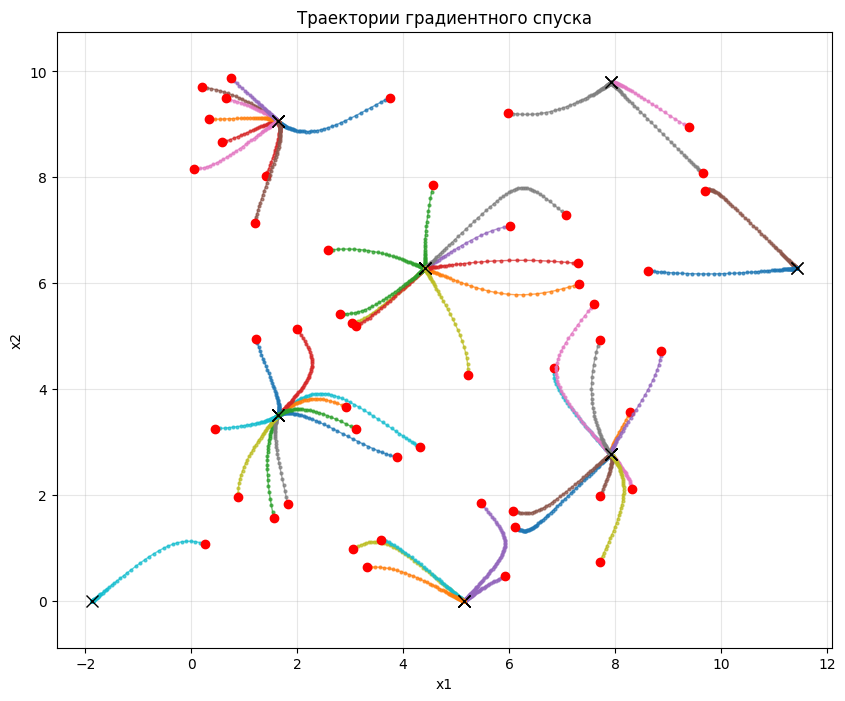

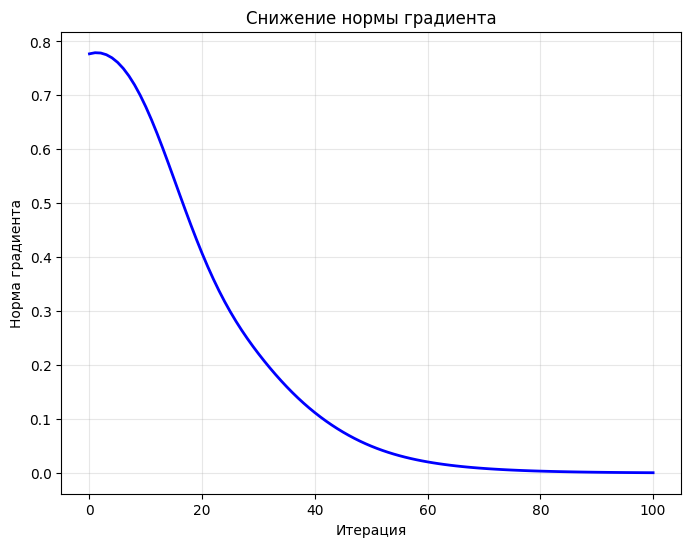

Сходимость достигнута на 66 итерации


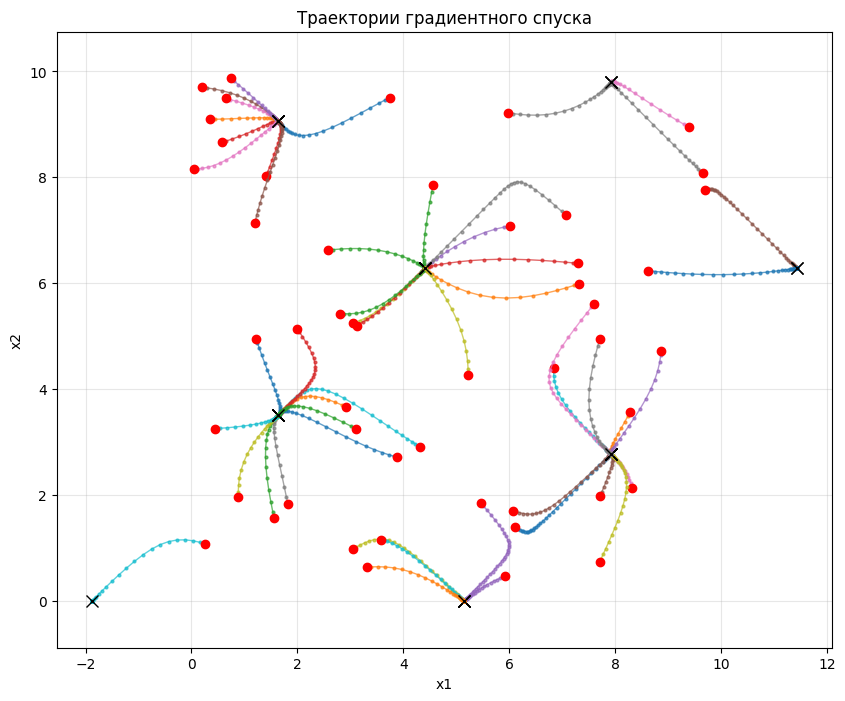

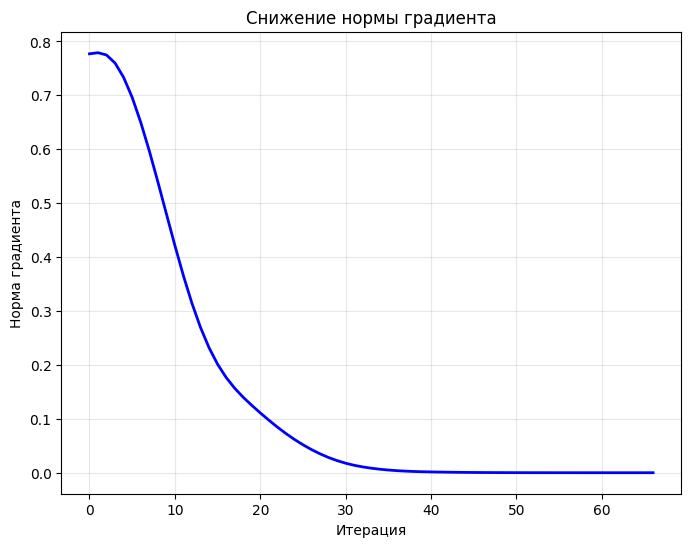

In [102]:
demonstrate_gradient_descent(50, False)
demonstrate_gradient_descent(50, True)